In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


data/TFIM_QUENCH/Feb11/L_8/CNN_K_6_C_(5_4_3)/seed_100/Ns_SR_4096/hc_mult_0.100/T_4.000/Ns_TVMC_65536/ log
Restored
[array(nan), array(2.42386735e-07), array(1.82103237e-07), array(5.14629084e-07), array(3.95666111e-07), array(5.66062356e-07), array(6.93243468e-07), array(4.86134454e-07), array(1.0442859e-06), array(9.14700165e-07), array(8.47033627e-07), array(4.39745122e-07), array(9.94081953e-07), array(7.91576905e-07), array(4.57952611e-07), array(1.10901674e-06), array(8.42547281e-07), array(6.97479161e-07), array(7.9505956e-07), array(1.1155811e-06), array(1.05018464e-06), array(7.11174773e-07), array(6.46744126e-07), array(9.94087248e-07), array(7.53721875e-07), array(6.46378906e-07), array(1.1483046e-06), array(8.68707162e-07), array(8.71264858e-07), array(8.94257015e-07), array(7.12006681e-07), array(8.31364871e-07), array(6.35703106e-07), array(7.53092398e-07), array(8.87591804e-07), array(1.12602825e-06), array(8.14953956e-07), array(6.27744418e-07), array(1.04014319e-06), ar

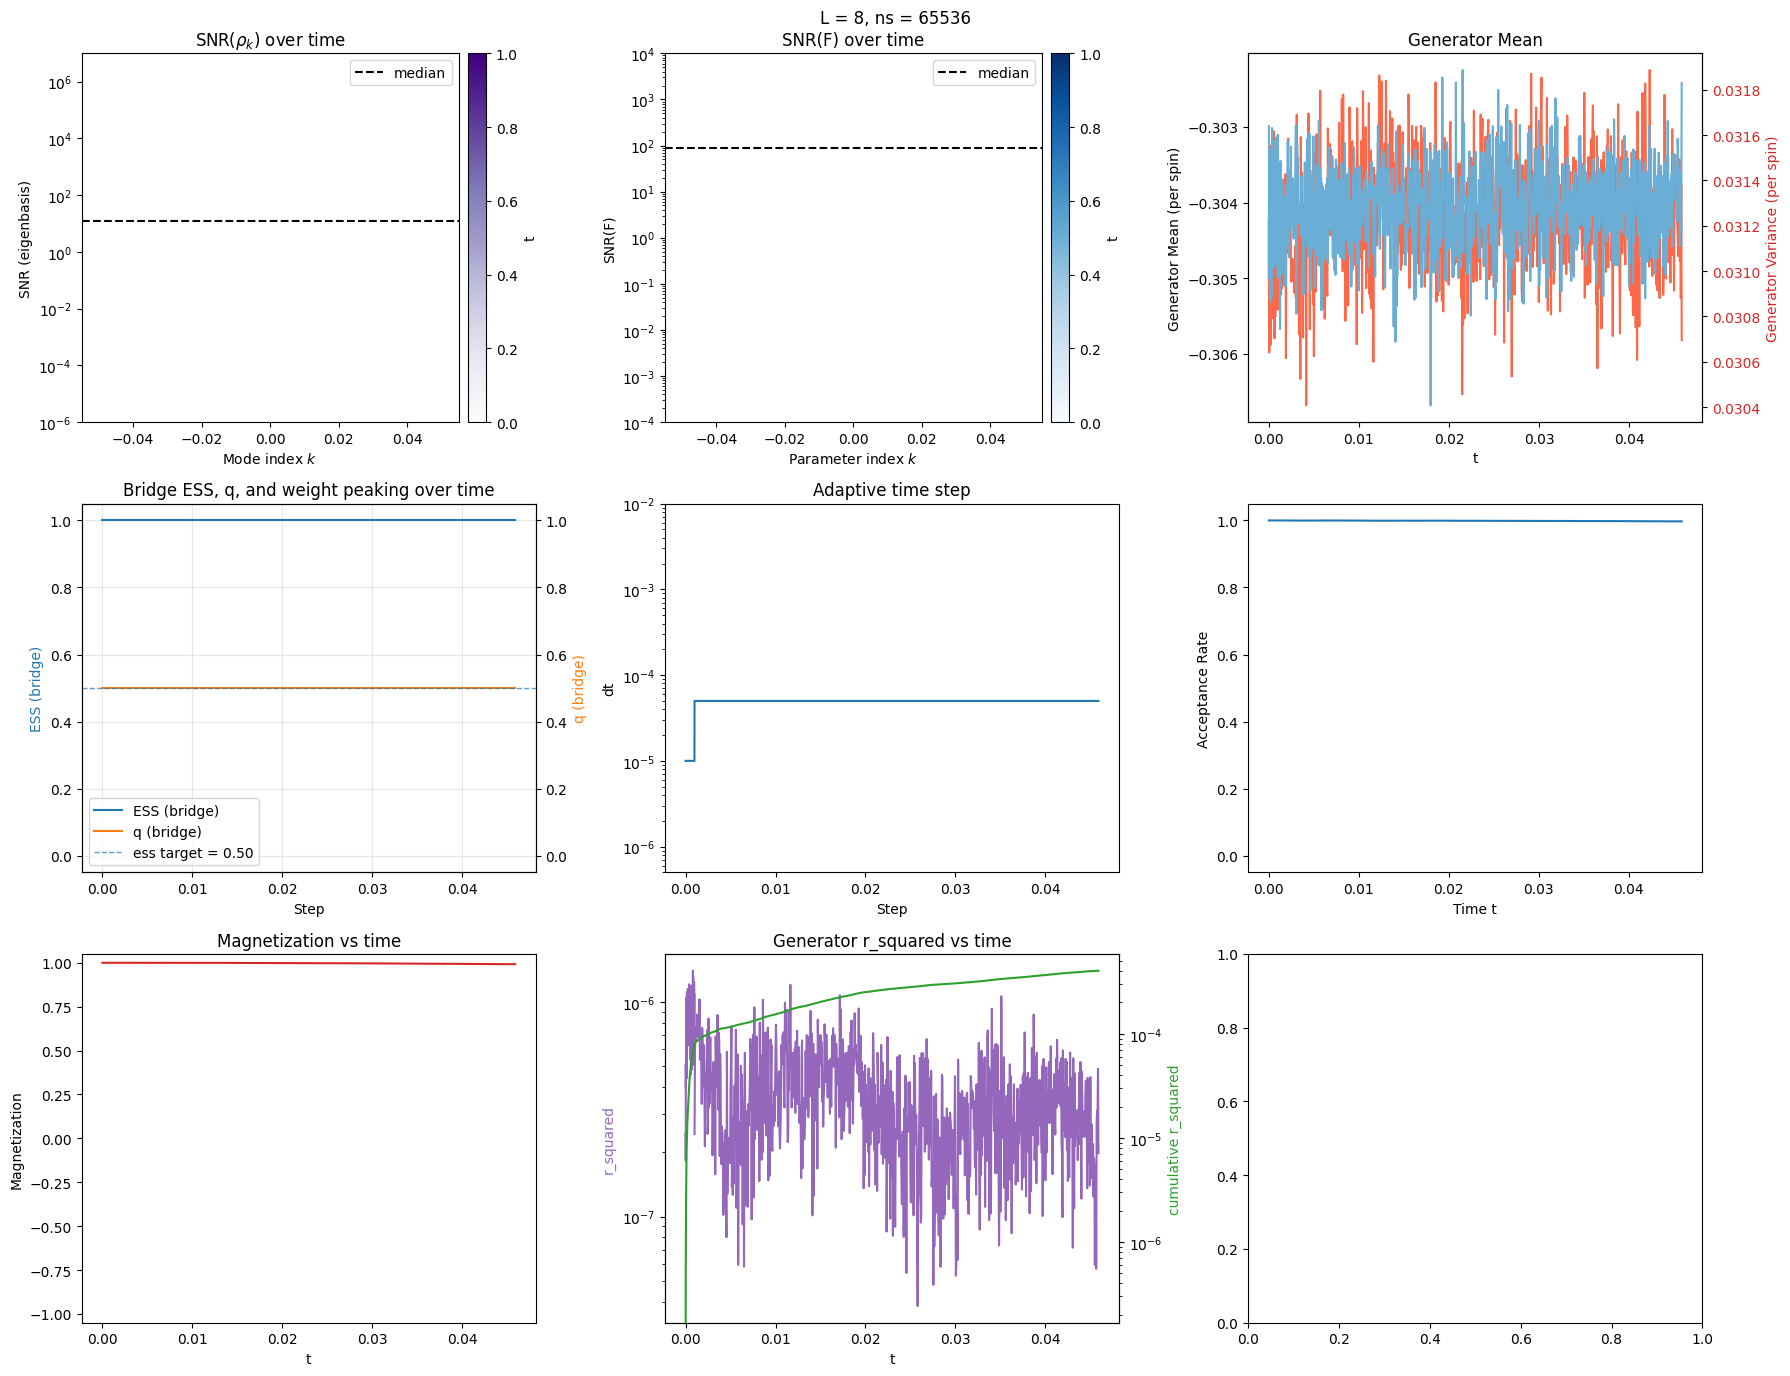

In [7]:
import os
import sys

sys.path.append("../src")

from logger import Logger
from tfim_quench_experiment import get_save_path, fields_to_track

import matplotlib.pyplot as plt
from matplotlib import colors

import numpy as np


def plot(config):
    _, save_path = get_save_path(config)
    logger = Logger(save_path, fields=fields_to_track)
    L = config["L"]
    seed = config["seed"]
    ns = config["n_samples_tvmc"]
    print(logger._path, logger._log_name)
    assert logger.restore()
    print("Restored")
    # Color ramp for per-step sorted curves
    n_colors = 20
    color_values = np.linspace(0, 1, n_colors, endpoint=False)

    # alpha0 = config["alpha0"]
    # Create 3x3 figure layout
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    ax_snr = axes[0, 0]
    ax_snrF = axes[0, 1]
    ax_gen_mean = axes[0, 2]
    ax_essq = axes[1, 0]
    ax_dt = axes[1, 1]
    # ax_gen_var becomes a twin axis of ax_gen_mean (right y-axis)
    # so we delete the unused subplot slot.
    ax_gen_var = ax_gen_mean.twinx()
    ax_ar = axes[1, 2]
    ax_Hcert = axes[2, 0]
    ax_rsq = axes[2, 1]
    ax_evs = axes[2, 2]

    # Top-left: SNR (eigenbasis) sorted curves with log y; add median and min lines
    snr_len = len(logger.data.get("snr", {}).get("values", []))
    cmap_snr = plt.get_cmap("Purples")
    # Normalize step index to [0,1] for colorbar
    norm_frac = colors.Normalize(vmin=0.0, vmax=1.0)
    for i in range(snr_len):
        snr_data = np.array(logger.data["snr"]["values"][i]).flatten()
        frac = 0.0 if snr_len <= 1 else i / (snr_len - 1)
        ax_snr.plot(np.sort(snr_data), color=cmap_snr(norm_frac(frac)))
    # Summary lines from monitor
    snr_med_series = logger.data.get("snr_med", {}).get("values", [])
    snr_min_series = logger.data.get("snr_min", {}).get("values", [])
    if len(snr_med_series) > 0:
        ax_snr.axhline(
            np.array(snr_med_series)[-1],
            color="black",
            linestyle="--",
            label="median",
        )
    # if len(snr_min_series) > 0:
    #     ax_snr.axhline(np.array(snr_min_series)[-1], color="gray", linestyle=":", label="min")
    ax_snr.set_xlabel(r"Mode index $k$")
    ax_snr.set_ylabel("SNR (eigenbasis)")
    ax_snr.set_title(rf"SNR($\rho_k$) over time")
    ax_snr.set_yscale("log")
    ax_snr.set_ylim([1e-6, 1e7])
    ax_snr.legend(loc="best")
    # Add colorbar for normalized step [0,1]
    sm_snr = plt.cm.ScalarMappable(cmap=cmap_snr, norm=norm_frac)
    sm_snr.set_array([])
    fig.colorbar(sm_snr, ax=ax_snr, pad=0.02, label="t")

    # Top-middle: SNR(F) sorted curves with log y; add median and min lines
    snrF_len = len(logger.data.get("snr_F", {}).get("values", []))
    cmap_snrF = plt.get_cmap("Blues")
    for i in range(snrF_len):
        snr_F_data = np.array(logger.data["snr_F"]["values"][i]).flatten()
        frac = 0.0 if snrF_len <= 1 else i / (snrF_len - 1)
        ax_snrF.plot(np.sort(snr_F_data), color=cmap_snrF(norm_frac(frac)))
    snrF_med_series = logger.data.get("snrF_med", {}).get("values", [])
    snrF_min_series = logger.data.get("snrF_min", {}).get("values", [])
    if len(snrF_med_series) > 0:
        ax_snrF.axhline(
            np.array(snrF_med_series)[-1],
            color="black",
            linestyle="--",
            label="median",
        )
    # if len(snrF_min_series) > 0:
    #     ax_snrF.axhline(np.array(snrF_min_series)[-1], color="gray", linestyle=":", label="min")
    ax_snrF.set_xlabel(r"Parameter index $k$")
    ax_snrF.set_ylabel("SNR(F)")
    ax_snrF.set_title(rf"SNR(F) over time")
    ax_snrF.set_yscale("log")
    ax_snrF.set_ylim([1e-4, 1e4])
    ax_snrF.legend(loc="best")
    # Add colorbar for normalized step [0,1]
    sm_snrF = plt.cm.ScalarMappable(cmap=cmap_snrF, norm=norm_frac)
    sm_snrF.set_array([])
    fig.colorbar(sm_snrF, ax=ax_snrF, pad=0.02, label="t")

    # Top-right: Generator mean
    generator_len = len(logger.data.get("Generator", {}).get("Mean", []))
    cmap_generator = plt.get_cmap("Reds")
    cmap_generator_2 = plt.get_cmap("Blues")
    generator_mean_data = (np.array(logger.data["Generator"]["Mean"])).flatten()
    times = np.array(logger.data["t"]["values"][:generator_len])
    ax_gen_mean.plot(
        times,
        np.real(generator_mean_data) / L**2,
        color=cmap_generator(norm_frac(0.5)),
        label="E[H]",
    )
    ax_gen_mean.set_xlabel(r"t")
    ax_gen_mean.set_ylabel("Generator Mean (per spin)")
    ax_gen_mean.set_title(rf"Generator Mean")

    # Right axis (twin): Generator variance (log-scale)
    generator_len = len(logger.data.get("Generator", {}).get("Variance", []))
    if generator_len > 0:
        generator_var_data = (np.array(logger.data["Generator"]["Variance"])).flatten()
        times_var = np.array(logger.data["t"]["values"][:generator_len])
        gen_var = np.real(generator_var_data) / L**4
        # Avoid log-scale crashes: mask non-positive values.
        gen_var = np.where(gen_var > 0.0, gen_var, np.nan)
        ax_gen_var.plot(
            times_var,
            gen_var,
            color=cmap_generator_2(norm_frac(0.5)),
            label="Var[H]",
        )
    ax_gen_var.set_ylabel(
        "Generator Variance (per spin)", color=cmap_generator(norm_frac(0.7))
    )
    ax_gen_var.tick_params(axis="y", labelcolor=cmap_generator(norm_frac(0.7)))
    # # Only enable log scale if there is at least one positive value.
    # if generator_len > 0 and np.any(np.isfinite(gen_var)):
    #     ax_gen_var.set_yscale("log")
    x_vals = logger.data["t"]["values"]
    ar_vals = logger.data["acceptance_rate"]["values"]
    ax_ar.plot(x_vals, ar_vals)
    ax_ar.set_ylim(-0.05,1.05)
    ax_ar.set_ylabel("Acceptance Rate")
    ax_ar.set_xlabel("Time t")
    # Bottom-left: ESS (left y) and q_bridge (right y) with max_weight_over_mean on left y
    x_vals = logger.data["t"]["values"]
    ess_vals = logger.data["ess_bridge"]["values"]
    q_vals = logger.data["q_bridge"]["values"]
    if ess_vals and q_vals:

        ax_right = ax_essq.twinx()
        (line1,) = ax_essq.plot(
            x_vals, ess_vals, color="tab:blue", label="ESS (bridge)"
        )
        # Also plot max_weight_over_mean on left axis
        (line2,) = ax_right.plot(x_vals, q_vals, color="tab:orange", label="q (bridge)")
        target_ess = 0.5
        ax_right.axhline(
            target_ess,
            color="tab:blue",
            linestyle="--",
            linewidth=1,
            alpha=0.7,
            label=f"ess target = {target_ess:1.2f}",
        )

        ax_essq.set_xlabel("Step")
        ax_essq.set_ylabel("ESS (bridge)", color="tab:blue")
        ax_right.set_ylabel("q (bridge)", color="tab:orange")
        # ax_essq.set_yscale("log")
        ax_essq.set_ylim(-0.05, 1.05)
        ax_right.set_ylim(-0.05, 1.05)
        ax_essq.grid(True, alpha=0.3)
        ax_essq.set_title("Bridge ESS, q, and weight peaking over time")

        lines = [line1, line2]
        labels = [l.get_label() for l in lines]
        # Include max_weight_over_mean if present
        ax_essq.legend(
            lines + [ax_right.lines[-1]],
            labels + [f"ess target = {target_ess:1.2f}"],
            loc="best",
        )

    # Bottom-middle: dt over steps
    ax_dt.plot(x_vals, logger.data["dt"]["values"])
    ax_dt.set_xlabel("Step")
    ax_dt.set_ylabel("dt")
    ax_dt.set_title("Adaptive time step")
    ax_dt.set_yscale("log")
    ax_dt.set_ylim([5e-7, 1e-2])

    # plt.tight_layout()
    # Bottom row: certification energy and r_squared over time
    times = logger.data["t"]["values"]
    mx = logger.data["mx"]["Mean"]
    ax_Hcert.plot(times, np.real(np.array(mx)), color="tab:red")
    ax_Hcert.set_xlabel("t")
    ax_Hcert.set_ylabel("Magnetization")
    ax_Hcert.set_title("Magnetization vs time")
    ax_Hcert.set_ylim(-1.05,1.05)
    # # QGT spectrum:
    # times = np.linspace(0.0, 1.0, 20)
    # eigenvalues = []
    # eigenvalues_reg = []
    # for i in range(20):
    #     save_path_ev = save_path + f"{eo}/ev_{i}.npy"
    #     save_path_ev_reg = save_path + f"{eo}/ev_reg_{i}.npy"
    #     try:
    #         ev = np.load(save_path_ev)
    #         ev_reg = np.load(save_path_ev_reg)
    #         perm = np.argsort(ev)
    #         ev = ev[perm]
    #         ev_reg = ev_reg[perm]

    #         eigenvalues.append(ev)
    #         eigenvalues_reg.append(ev_reg)
    #     except FileNotFoundError:
    #         break
    # number_of_eigenvalues = min(len(eigenvalues), len(eigenvalues_reg))
    # t_vals_cert = times[: len(eigenvalues)]
    # cmap_generator_2 = plt.get_cmap("Blues")
    # for i in range(number_of_eigenvalues):
    #     frac = (
    #         0.0 if number_of_eigenvalues <= 1 else i / (number_of_eigenvalues - 1)
    #     )
    #     ev = eigenvalues[i]f
    #     ev_reg = eigenvalues_reg[i]
    #     ax_evs.plot(ev, color=cmap_generator(norm_frac(frac)))
    #     ax_evs.plot(ev_reg, color=cmap_generator_2(norm_frac(frac)), linestyle="--")

    # ax_evs.set_xlabel("Parameter index $k$")
    # ax_evs.set_ylabel(r"Eigenvalue $\lambda_k/\lambda_\max$")
    # ax_evs.set_title("QGT eigenvalues")
    # ax_evs.set_yscale("log")
    # Add cumulative r_squared on right axis
    t_vals = logger.data["t"]["values"]
    r_sq = logger.data["r_squared"]["values"]
    print(r_sq)
    ax_rsq.plot(t_vals, r_sq, color="tab:purple")
    ax_rsq.set_xlabel("t")
    ax_rsq.set_ylabel("r_squared", color="tab:purple")
    ax_rsq.set_title("Generator r_squared vs time")
    r_sq_arr = np.array(r_sq, dtype=float)
    if np.any(np.isfinite(r_sq_arr) & (r_sq_arr > 0.0)):
        ax_rsq.set_yscale("log")

    ax_rsq_right = ax_rsq.twinx()
    r_sq_arr = np.array(r_sq, dtype=float)
    r_sq_cum = np.nancumsum(r_sq_arr)
    ax_rsq_right.plot(t_vals, r_sq_cum, color="tab:green", label="cumulative r_squared")
    ax_rsq_right.set_ylabel("cumulative r_squared", color="tab:green")
    ax_rsq_right.tick_params(axis="y")
    ax_rsq_right.set_yscale("log")

    plt.suptitle(rf"L = {L}, ns = {ns}")
    plt.tight_layout()
    figpath = f"./figures/{save_path}"

    if not os.path.exists(figpath):
        os.makedirs(figpath)
    plt.savefig(f"{figpath}/bridge_{seed}.pdf")
    plt.show()


config = {
    "experiment_name": "Feb11",
    "data_prepend": "./data",
    "L": 8,
    "seed": 100,
    "n_samples_sr": 2**12,
    "n_samples_tvmc": 2**16,
    "hc_multiplier": 0.1,
    "T": 4.0,
    "n_save_times": 20,
    "kernel_size": 6,
    "channels": (5, 4, 3),
}
plot(config)